# Frequency Analysis of LFP

### Demo Frequency Analysis

In [1]:
from scipy import signal
import pywt

import numpy as np
import matplotlib.pyplot as plt

#### Apply Welch's Method to Get Total Frequency Content of Signal in Time Period

Generate composite signal that's a mix between a sine wave, a chirp signal, and noise.

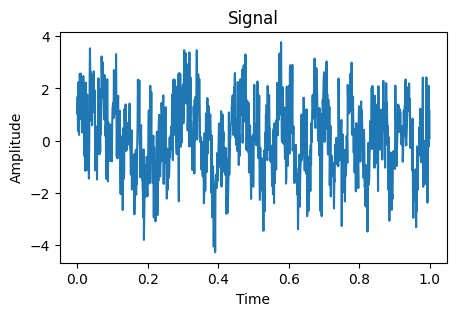

In [4]:
np.random.seed(4)
# Create composite signal
sampling_frequency = 1000
time_vec = np.linspace(0,1,sampling_frequency) # seconds
frequency = 30 # Hz
sineA = np.sin(2*np.pi*frequency*time_vec)

chirp_signal = signal.chirp(time_vec, f0=1, f1=15, t1=1)

noise = np.random.normal(0,1,len(time_vec))

composite_signal = sineA+chirp_signal+noise

plt.figure(figsize=(5,3))
plt.plot(time_vec,composite_signal)
plt.title('Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude');

Compute and plot frequency spectrum

- NB: the parameters `nperseg` and `noverlap` determines the trade-off between high resolution and the signal-to-noise ratio of the spectrum.

/gpfs/soma_fs/home/radadia/miniforge3/envs/npx/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 1024 is greater than input length  = 1000, using nperseg = 1000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


Text(0, 0.5, 'Power spectral density (normalized)')

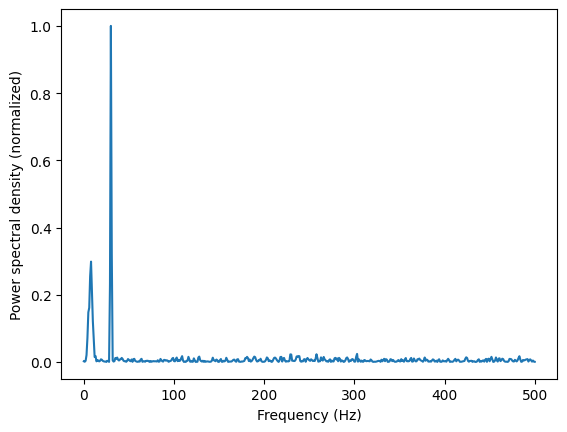

In [5]:
freqs, psd = signal.welch(composite_signal, fs = sampling_frequency, nperseg=1024)

# normalize
psd = psd/psd.max()

plt.plot(freqs, psd)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power spectral density (normalized)')

#### Demo Time-Resolved Frequency Analysis with Morlet Wavelets
- Provides information about frequency content over time in a recording.

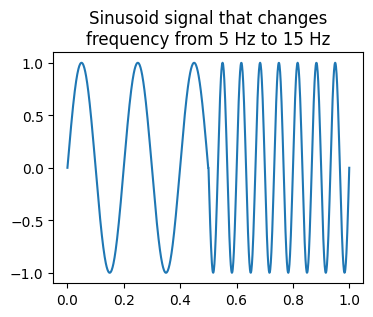

In [6]:
# provided

# Generate signal
sampling_frequency = 1000
durationA = 0.5
time_vecA = np.linspace(0,durationA,int(sampling_frequency*durationA)) # seconds
frequencyA = 5 # Hz
sineA = np.sin(2*np.pi*frequencyA*time_vecA)

durationB = 0.5
time_vecB = np.linspace(durationA, durationA+durationB, int(sampling_frequency*durationB)) # seconds
frequencyB = 15 # Hz
sineB = np.sin(2*np.pi*frequencyB*time_vecB)

time_vec = np.linspace(0,durationA+durationB,int(sampling_frequency*(durationA+durationB)))
sig = np.concatenate([sineA,sineB])

plt.figure(figsize=(4,3))
plt.plot(time_vec,sig)
plt.title(f'Sinusoid signal that changes\nfrequency from {frequencyA} Hz to {frequencyB} Hz');

NB: The ``bandwidth`` and ``center_frequency`` parameters determines the trade-off between time- and frequency resolution.

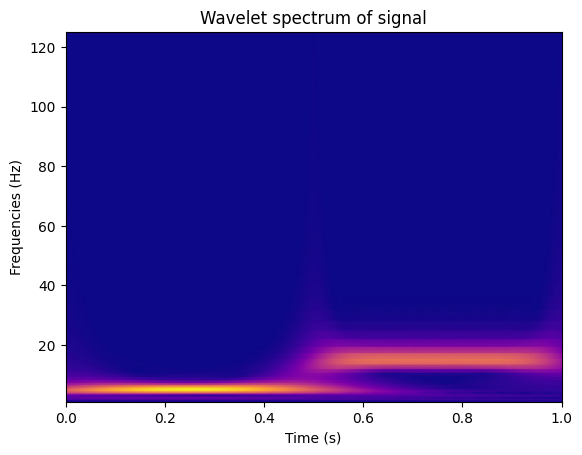

In [7]:
# compute the time-resolved frequency spectrum

number_of_freqs = 40
bandwidth = 1.5
center_frequency = 1.0

# the bandwidth and the central frequency determines which Morlet wavelet is used
wavelet = "cmor"+str(bandwidth)+"-"+str(center_frequency)

# widths of the Morlet wavelet determines which frequencies the wavelet spectrum is calculated for
widths = np.logspace(start=3, stop=10, num=number_of_freqs, base=2)

sampling_period = 1/sampling_frequency
spectrum, freqs = pywt.cwt(sig, widths, wavelet, sampling_period=sampling_period)

# take absolute value to get real part and therefore amplitude of spectrum
spectrum_amp = np.abs(spectrum)

plt.pcolormesh(time_vec, freqs, spectrum_amp, cmap = 'plasma', shading='gouraud')
plt.xlabel('Time (s)')
plt.ylabel('Frequencies (Hz)')
plt.title('Wavelet spectrum of signal');

## Apply Frequency Analysis Methods to Processed Data

In [2]:
from pathlib import Path
import os

import warnings
warnings.simplefilter("ignore")

import spikeinterface.full as si
print(f"SpikeInterface version: {si.__version__}")

job_kwargs = dict(n_jobs=40, chunk_duration='1s', progress_bar=True)

SpikeInterface version: 0.102.3


In [3]:
rec_folder = r"../data/FA1680378B/Day6_CntrlCntrlCntrl_Shank4BankA/NeuralData/3Cntrl/2024-08-10_21-31-59"
raw_rec = si.read_openephys(rec_folder, stream_id = '1')
print('Recording properties:\n', list(raw_rec.get_property_keys()))

sampling_frequency = raw_rec.get_sampling_frequency()
num_channels = raw_rec.get_num_channels()

print(f"Sampling frequency: {sampling_frequency} Hz")
print(f"Number of channels: {num_channels}")

Recording properties:
 ['gain_to_uV', 'offset_to_uV', 'physical_unit', 'gain_to_physical_unit', 'offset_to_physical_unit', 'channel_name', 'contact_vector', 'location', 'group', 'inter_sample_shift']
Sampling frequency: 30000.0 Hz
Number of channels: 384


In [4]:
import probeinterface as pi
from probeinterface.plotting import plot_probe

probe = raw_rec.get_probe()
print(probe)

Probe - 384ch - 1shanks


In [4]:
def preprocess_chain(rec):
    rec = si.phase_shift(rec)
    bad_channel_ids, channel_labels = si.detect_bad_channels(rec)
    rec = rec.remove_channels(bad_channel_ids)
    rec = si.bandpass_filter(rec, freq_min=0.5, freq_max=500, dtype='float32')
    rec = si.common_reference(rec, reference='global', operator='median')
    return rec

In [6]:
##### ONLY RUN IF YOU WANT TO PROCESS THE RECORDING #####
preproc_rec = preprocess_chain(raw_rec)

downsample_quotient = 30
new_sampling_frequency = int(sampling_frequency / downsample_quotient)
ds_preproc_rec = si.resample(preproc_rec, resample_rate = new_sampling_frequency)

ds_preproc_rec = ds_preproc_rec.save(folder=rec_folder + '_00_preprocess', format='binary', overwrite=True, **job_kwargs)

write_binary_recording 
engine=process - n_jobs=40 - samples_per_chunk=1,000 - chunk_memory=1.45 MiB - total_memory=57.98 MiB - chunk_duration=1.00s


write_binary_recording (workers: 40 processes):   0%|          | 0/628 [00:00<?, ?it/s]

In [5]:
##### RUN THIS TO LOAD THE PROCESSED RECORDING #####
ds_preproc_rec1 = si.load_extractor(rec_folder + '_00_preprocess')
ds_preproc_rec1

BinaryFolderRecording: 380 channels - 1000.0Hz - 1 segments - 627,966 samples 
                       627.97s (10.47 minutes) - float32 dtype - 910.29 MiB

In [16]:
ds_preproc_rec1.get_time_info()

{'sampling_frequency': 1000.0, 't_start': 3.9936, 'time_vector': None}

In [17]:
ds_preproc_rec1.get_channel_ids()

array(['CH1', 'CH2', 'CH3', 'CH4', 'CH5', 'CH6', 'CH7', 'CH8', 'CH9',
       'CH10', 'CH11', 'CH12', 'CH13', 'CH14', 'CH15', 'CH16', 'CH17',
       'CH18', 'CH19', 'CH20', 'CH21', 'CH22', 'CH23', 'CH24', 'CH25',
       'CH26', 'CH27', 'CH28', 'CH29', 'CH30', 'CH31', 'CH32', 'CH33',
       'CH34', 'CH35', 'CH36', 'CH37', 'CH38', 'CH39', 'CH40', 'CH41',
       'CH42', 'CH43', 'CH44', 'CH45', 'CH46', 'CH47', 'CH48', 'CH49',
       'CH50', 'CH51', 'CH52', 'CH53', 'CH54', 'CH55', 'CH56', 'CH57',
       'CH58', 'CH59', 'CH60', 'CH61', 'CH62', 'CH63', 'CH64', 'CH65',
       'CH66', 'CH67', 'CH68', 'CH69', 'CH70', 'CH71', 'CH72', 'CH73',
       'CH74', 'CH76', 'CH77', 'CH78', 'CH79', 'CH80', 'CH81', 'CH82',
       'CH83', 'CH84', 'CH85', 'CH86', 'CH87', 'CH88', 'CH89', 'CH90',
       'CH91', 'CH92', 'CH93', 'CH94', 'CH96', 'CH97', 'CH98', 'CH99',
       'CH100', 'CH101', 'CH102', 'CH103', 'CH104', 'CH105', 'CH106',
       'CH107', 'CH108', 'CH109', 'CH110', 'CH111', 'CH112', 'CH113',
       'C

In [18]:
ds_preproc_rec1.get_channel_locations()

array([[ 750., 1440.],
       [ 782., 1440.],
       [ 750., 1455.],
       [ 782., 1455.],
       [ 750., 1470.],
       [ 782., 1470.],
       [ 750., 1485.],
       [ 782., 1485.],
       [ 750., 1500.],
       [ 782., 1500.],
       [ 750., 1515.],
       [ 782., 1515.],
       [ 750., 1530.],
       [ 782., 1530.],
       [ 750., 1545.],
       [ 782., 1545.],
       [ 750., 1560.],
       [ 782., 1560.],
       [ 750., 1575.],
       [ 782., 1575.],
       [ 750., 1590.],
       [ 782., 1590.],
       [ 750., 1605.],
       [ 782., 1605.],
       [ 750., 1620.],
       [ 782., 1620.],
       [ 750., 1635.],
       [ 782., 1635.],
       [ 750., 1650.],
       [ 782., 1650.],
       [ 750., 1665.],
       [ 782., 1665.],
       [ 750., 1680.],
       [ 782., 1680.],
       [ 750., 1695.],
       [ 782., 1695.],
       [ 750., 1710.],
       [ 782., 1710.],
       [ 750., 1725.],
       [ 782., 1725.],
       [ 750., 1740.],
       [ 782., 1740.],
       [ 750., 1755.],
       [ 78

In [ ]:
ds_preproc_rec1.get_binary_description()

{'file_paths': ['/gpfs/soma_fs/nmr/NMR_group_data/Hemanya/data/FA1680378B/Day6_CntrlCntrlCntrl_Shank4BankA/NeuralData/3Cntrl/2024-08-10_21-31-59_00_preprocess/traces_cached_seg0.raw'],
 'dtype': dtype('float32'),
 'num_channels': 380,
 'time_axis': 0,
 'file_offset': 0}

In [24]:
ds_preproc_rec1.get_property_keys()

['gain_to_uV',
 'offset_to_uV',
 'contact_vector',
 'location',
 'group',
 'offset_to_physical_unit',
 'physical_unit',
 'gain_to_physical_unit',
 'inter_sample_shift',
 'channel_name']

In [ ]:
ds_preproc_rec1.get_property('c')

array(['CH1', 'CH2', 'CH3', 'CH4', 'CH5', 'CH6', 'CH7', 'CH8', 'CH9',
       'CH10', 'CH11', 'CH12', 'CH13', 'CH14', 'CH15', 'CH16', 'CH17',
       'CH18', 'CH19', 'CH20', 'CH21', 'CH22', 'CH23', 'CH24', 'CH25',
       'CH26', 'CH27', 'CH28', 'CH29', 'CH30', 'CH31', 'CH32', 'CH33',
       'CH34', 'CH35', 'CH36', 'CH37', 'CH38', 'CH39', 'CH40', 'CH41',
       'CH42', 'CH43', 'CH44', 'CH45', 'CH46', 'CH47', 'CH48', 'CH49',
       'CH50', 'CH51', 'CH52', 'CH53', 'CH54', 'CH55', 'CH56', 'CH57',
       'CH58', 'CH59', 'CH60', 'CH61', 'CH62', 'CH63', 'CH64', 'CH65',
       'CH66', 'CH67', 'CH68', 'CH69', 'CH70', 'CH71', 'CH72', 'CH73',
       'CH74', 'CH76', 'CH77', 'CH78', 'CH79', 'CH80', 'CH81', 'CH82',
       'CH83', 'CH84', 'CH85', 'CH86', 'CH87', 'CH88', 'CH89', 'CH90',
       'CH91', 'CH92', 'CH93', 'CH94', 'CH96', 'CH97', 'CH98', 'CH99',
       'CH100', 'CH101', 'CH102', 'CH103', 'CH104', 'CH105', 'CH106',
       'CH107', 'CH108', 'CH109', 'CH110', 'CH111', 'CH112', 'CH113',
       'C

In [31]:
ds_preproc_rec1.get_annotation('probes_info')

[{'name': 'ProbeA',
  'serial_number': '22420013971',
  'model_name': 'Neuropixels 2.0 - Four Shank',
  'manufacturer': 'IMEC',
  'part_number': 'NP2013',
  'slot': '3',
  'dock': '1',
  'port': '1'}]

#### Get traces of raw signal and processed signal for specific channel both before and after downsampling


In [25]:
# start and end frame of selected traces with original 30 kHz sampling rate
start_frame = 600000
end_frame = 1200000

In [ ]:
channel_id = 'CH295'
raw_trace = raw_rec.get_traces(start_frame = start_frame, end_frame= end_frame, channel_ids=[channel_id], return_scaled=True).squeeze(1)

processed_trace = preproc_rec.get_traces(start_frame = start_frame, end_frame= end_frame, channel_ids=[channel_id], return_scaled=True).squeeze(1)

processed_trace_ds = preproc_rec_ds.get_traces(start_frame = int(start_frame/downsample_quotient), end_frame= int(end_frame/downsample_quotient), channel_ids=[channel_id], return_scaled=True).squeeze(1)

In [6]:
channel_id = 'CH225'
#entire_trace_ds = preproc_rec_ds.get_traces(channel_ids=[channel_id], return_scaled=True).squeeze(1)
entire_trace_ds = []
frame_step = 100000
total_frames = ds_preproc_rec1.get_num_frames()

In [11]:
channel_id = 'CH225'
entire_trace_ds = ds_preproc_rec1.get_traces(return_scaled=True)
entire_timestamps = ds_preproc_rec1.get_times()

In [10]:
entire_trace_ds.shape

(627966, 380)

In [12]:
entire_timestamps.shape

(627966,)

In [29]:
for start_frame in range(0, total_frames, frame_step):
    end_frame = min(start_frame + frame_step, total_frames)
    trace_chunk = preproc_rec_ds.get_traces(start_frame=start_frame, end_frame=end_frame, channel_ids=[channel_id], return_scaled=True).squeeze(1)
    entire_trace_ds.append(trace_chunk)
    print(f"Processed frames {start_frame} to {end_frame}")

entire_trace_ds = np.concatenate(entire_trace_ds)

Processed frames 0 to 100000
Processed frames 100000 to 200000
Processed frames 200000 to 300000
Processed frames 300000 to 400000
Processed frames 400000 to 500000
Processed frames 500000 to 600000
Processed frames 600000 to 627966


#### Plot processed and unprocessed signals together

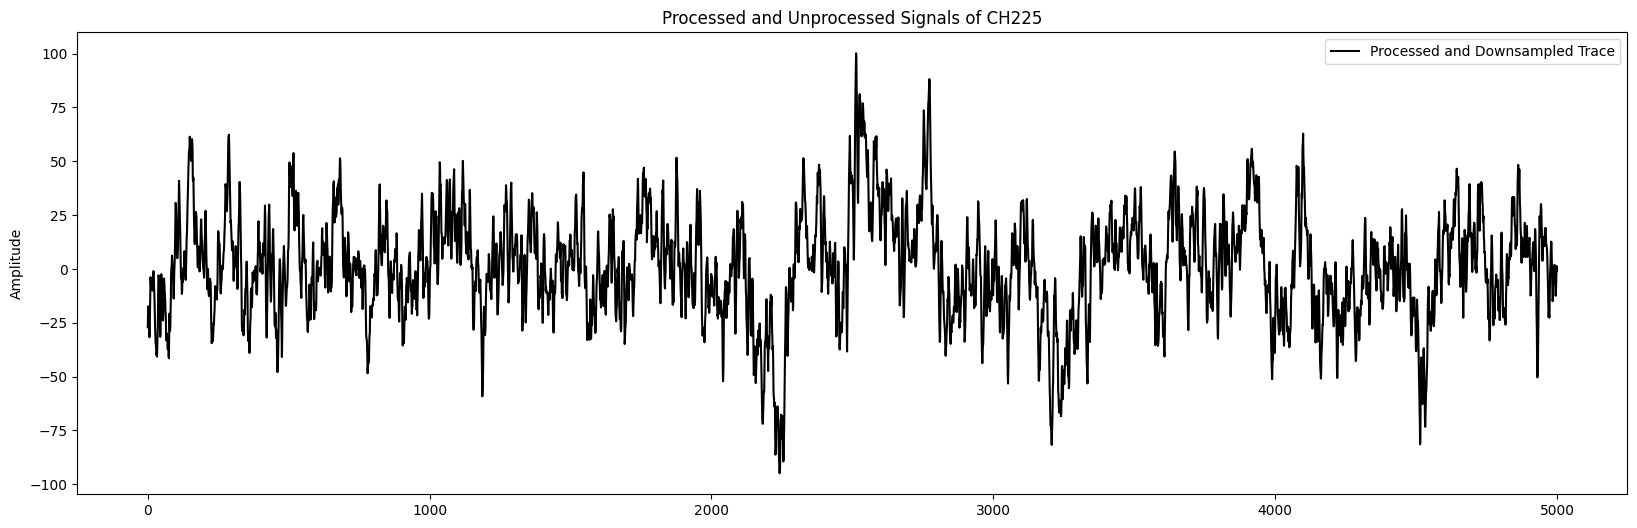

In [16]:
plt.figure(figsize=(20, 6))
#plt.plot(np.arange(start_frame, end_frame, 1), raw_trace, color='blue', alpha=0.9, label = f'Raw Trace')
#plt.plot(np.arange(start_frame, end_frame, 1)[::30], processed_trace[::30], color='red', alpha=0.9, label = f'Processed Trace')
#plt.plot(np.arange(start_frame, end_frame, downsample_quotient), processed_trace_ds, color='black', label = f'Processed and Downsampled Trace')
plt.plot(entire_trace_ds[100000:105000], color='black', label = f'Processed and Downsampled Trace')

plt.ylabel('Amplitude')
plt.title(f'Processed and Unprocessed Signals of {channel_id}')
plt.legend()

In [24]:
lfp_timestamps = ds_preproc_rec1.get_times()

In [26]:
len(lfp_timestamps)

627966

In [28]:
entire_trace_ds

array([-46.242516, -71.89741 , -71.18593 , ..., -25.401834, -27.774422,
       -18.074017], dtype=float32)

#### Calculate total frequency content of downsampled, processed signal

In [17]:
N = np.floor(len(entire_trace_ds) / 8)  # Use a quarter of the data length for nperseg
freqs, psd = signal.welch(entire_trace_ds, fs=1000, window='hamming', nperseg = N) #nfft should be greater than nperseg?

#freqs, psd = signal.welch(entire_trace_ds, fs = new_sampling_frequency, nperseg = 1024)

# normalize
psd = psd/psd.max()

Text(0.5, 0, 'Frequency (Hz)')

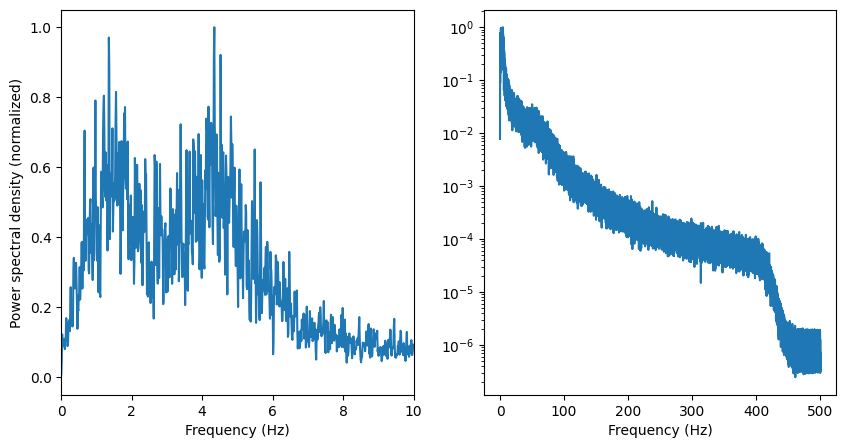

In [18]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize = (10,5))

ax = axes[0]
ax.plot(freqs, psd)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power spectral density (normalized)')
ax.set_xlim([0,10])

ax = axes[1]
ax.semilogy(freqs, psd)
ax.set_xlabel('Frequency (Hz)')
#ax.set_ylabel('Power spectral density (normalized)')
#ax.set_xlim([0,50])

#### Time-Resolved Frequency Spectrum of LFP

In [20]:
# compute the time-resolved frequency spectrum

number_of_freqs = 40
bandwidth = 1.5
center_frequency = 1.0

# the bandwidth and the central frequency sets which Morlet wavelet is used
wavelet = "cmor"+str(bandwidth)+"-"+str(center_frequency)

# widths of the Morlet wavelet determines which frequencies the wavelet spectrum is calculated for
widths = np.logspace(start=3, stop=10, num=number_of_freqs, base=2)

sampling_period = 1/new_sampling_frequency
spectrum, freqs = pywt.cwt(entire_trace_ds, widths, wavelet, sampling_period=sampling_period)

# take absolute value to get real part and therefore amplitude of spectrum
spectrum_amp = np.abs(spectrum)

(0.0, 10.0)

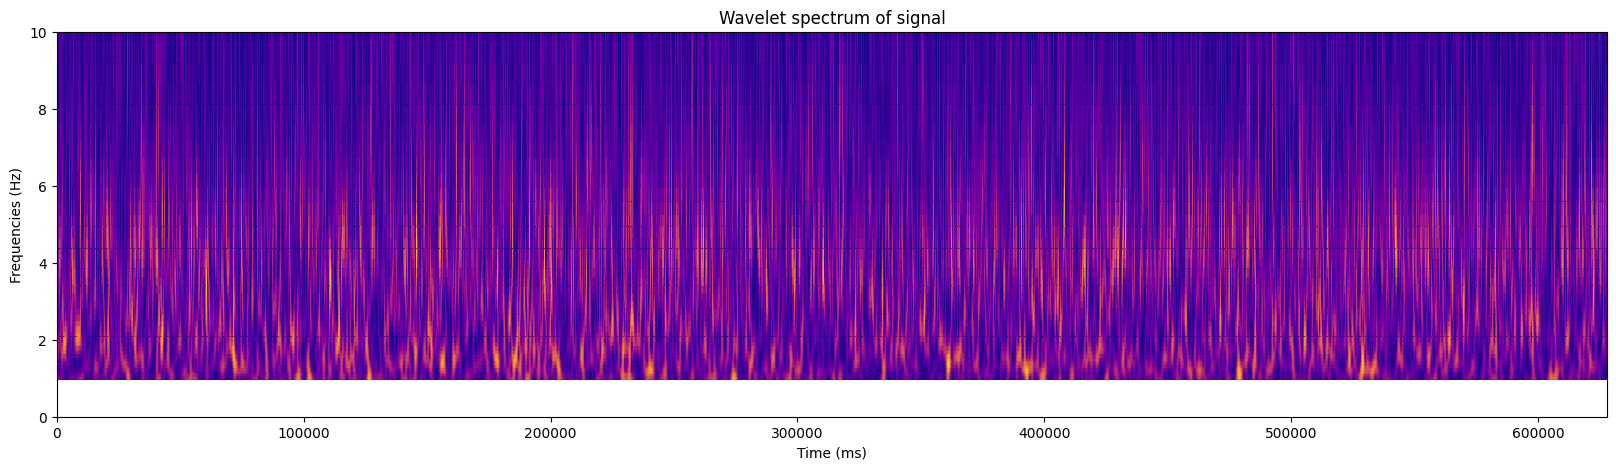

In [23]:
plt.figure(figsize=(20,5))
plt.pcolormesh(np.arange(0, len(entire_trace_ds), 1), freqs, spectrum_amp, cmap = 'plasma', shading='gouraud')
plt.xlabel('Time (ms)')
plt.ylabel('Frequencies (Hz)')
plt.title('Wavelet spectrum of signal');
#plt.xlim([0,5000])
plt.ylim([0,10])